# Unsupervised Learning on Country Data
<img src="images/country.png" height=60% width=60%>

# HELP International

HELP International is an international humanitarian NGO that is committed to fighting poverty and providing the people of backward countries with basic amenities and relief during the time of disasters and natural calamities.

## Problem Statement

HELP International have been able to raise around $ 10 million. Now the CEO of the NGO needs to decide how to use this money strategically and effectively. So, CEO has to make decision to choose the countries that are in the direst need of aid. Hence, your Job as a Data scientist is to categorise the countries using some socio-economic and health factors that determine the overall development of the country. Then you need to suggest the countries which the CEO needs to focus on the most.

## Objective

To categorise the countries using socio-economic and health factors that determine the overall development of the country.

# Preview Data

In [10]:
# import pandas
import pandas as pd
# read data
country = pd.read_csv('Data Zip/archive/Country-data.csv')
# data info
country.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [11]:
# first 5 rows
country.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Description of Columns:
* **country** - Name of the country
* **child_mort** - Death of children under 5 years of age per 1000 live births
* **exports** - Exports of goods and services per capita. Given as %age of the GDP per capita
* **health** - Total health spending per capita. Given as %age of GDP per capita
* **imports** - Imports of goods and services per capita. Given as %age of the GDP per capita
* **Income** - Net income per person
* **Inflation** - The measurement of the annual growth rate of the Total GDP
* **life_expec** - The average number of years a new born child would live if the current mortality patterns are to remain the same
* **total_fer** - The number of children that would be born to each woman if the current age-fertility rates remain the same.
* **gdpp** - The GDP per capita. Calculated as the Total GDP divided by the total population.


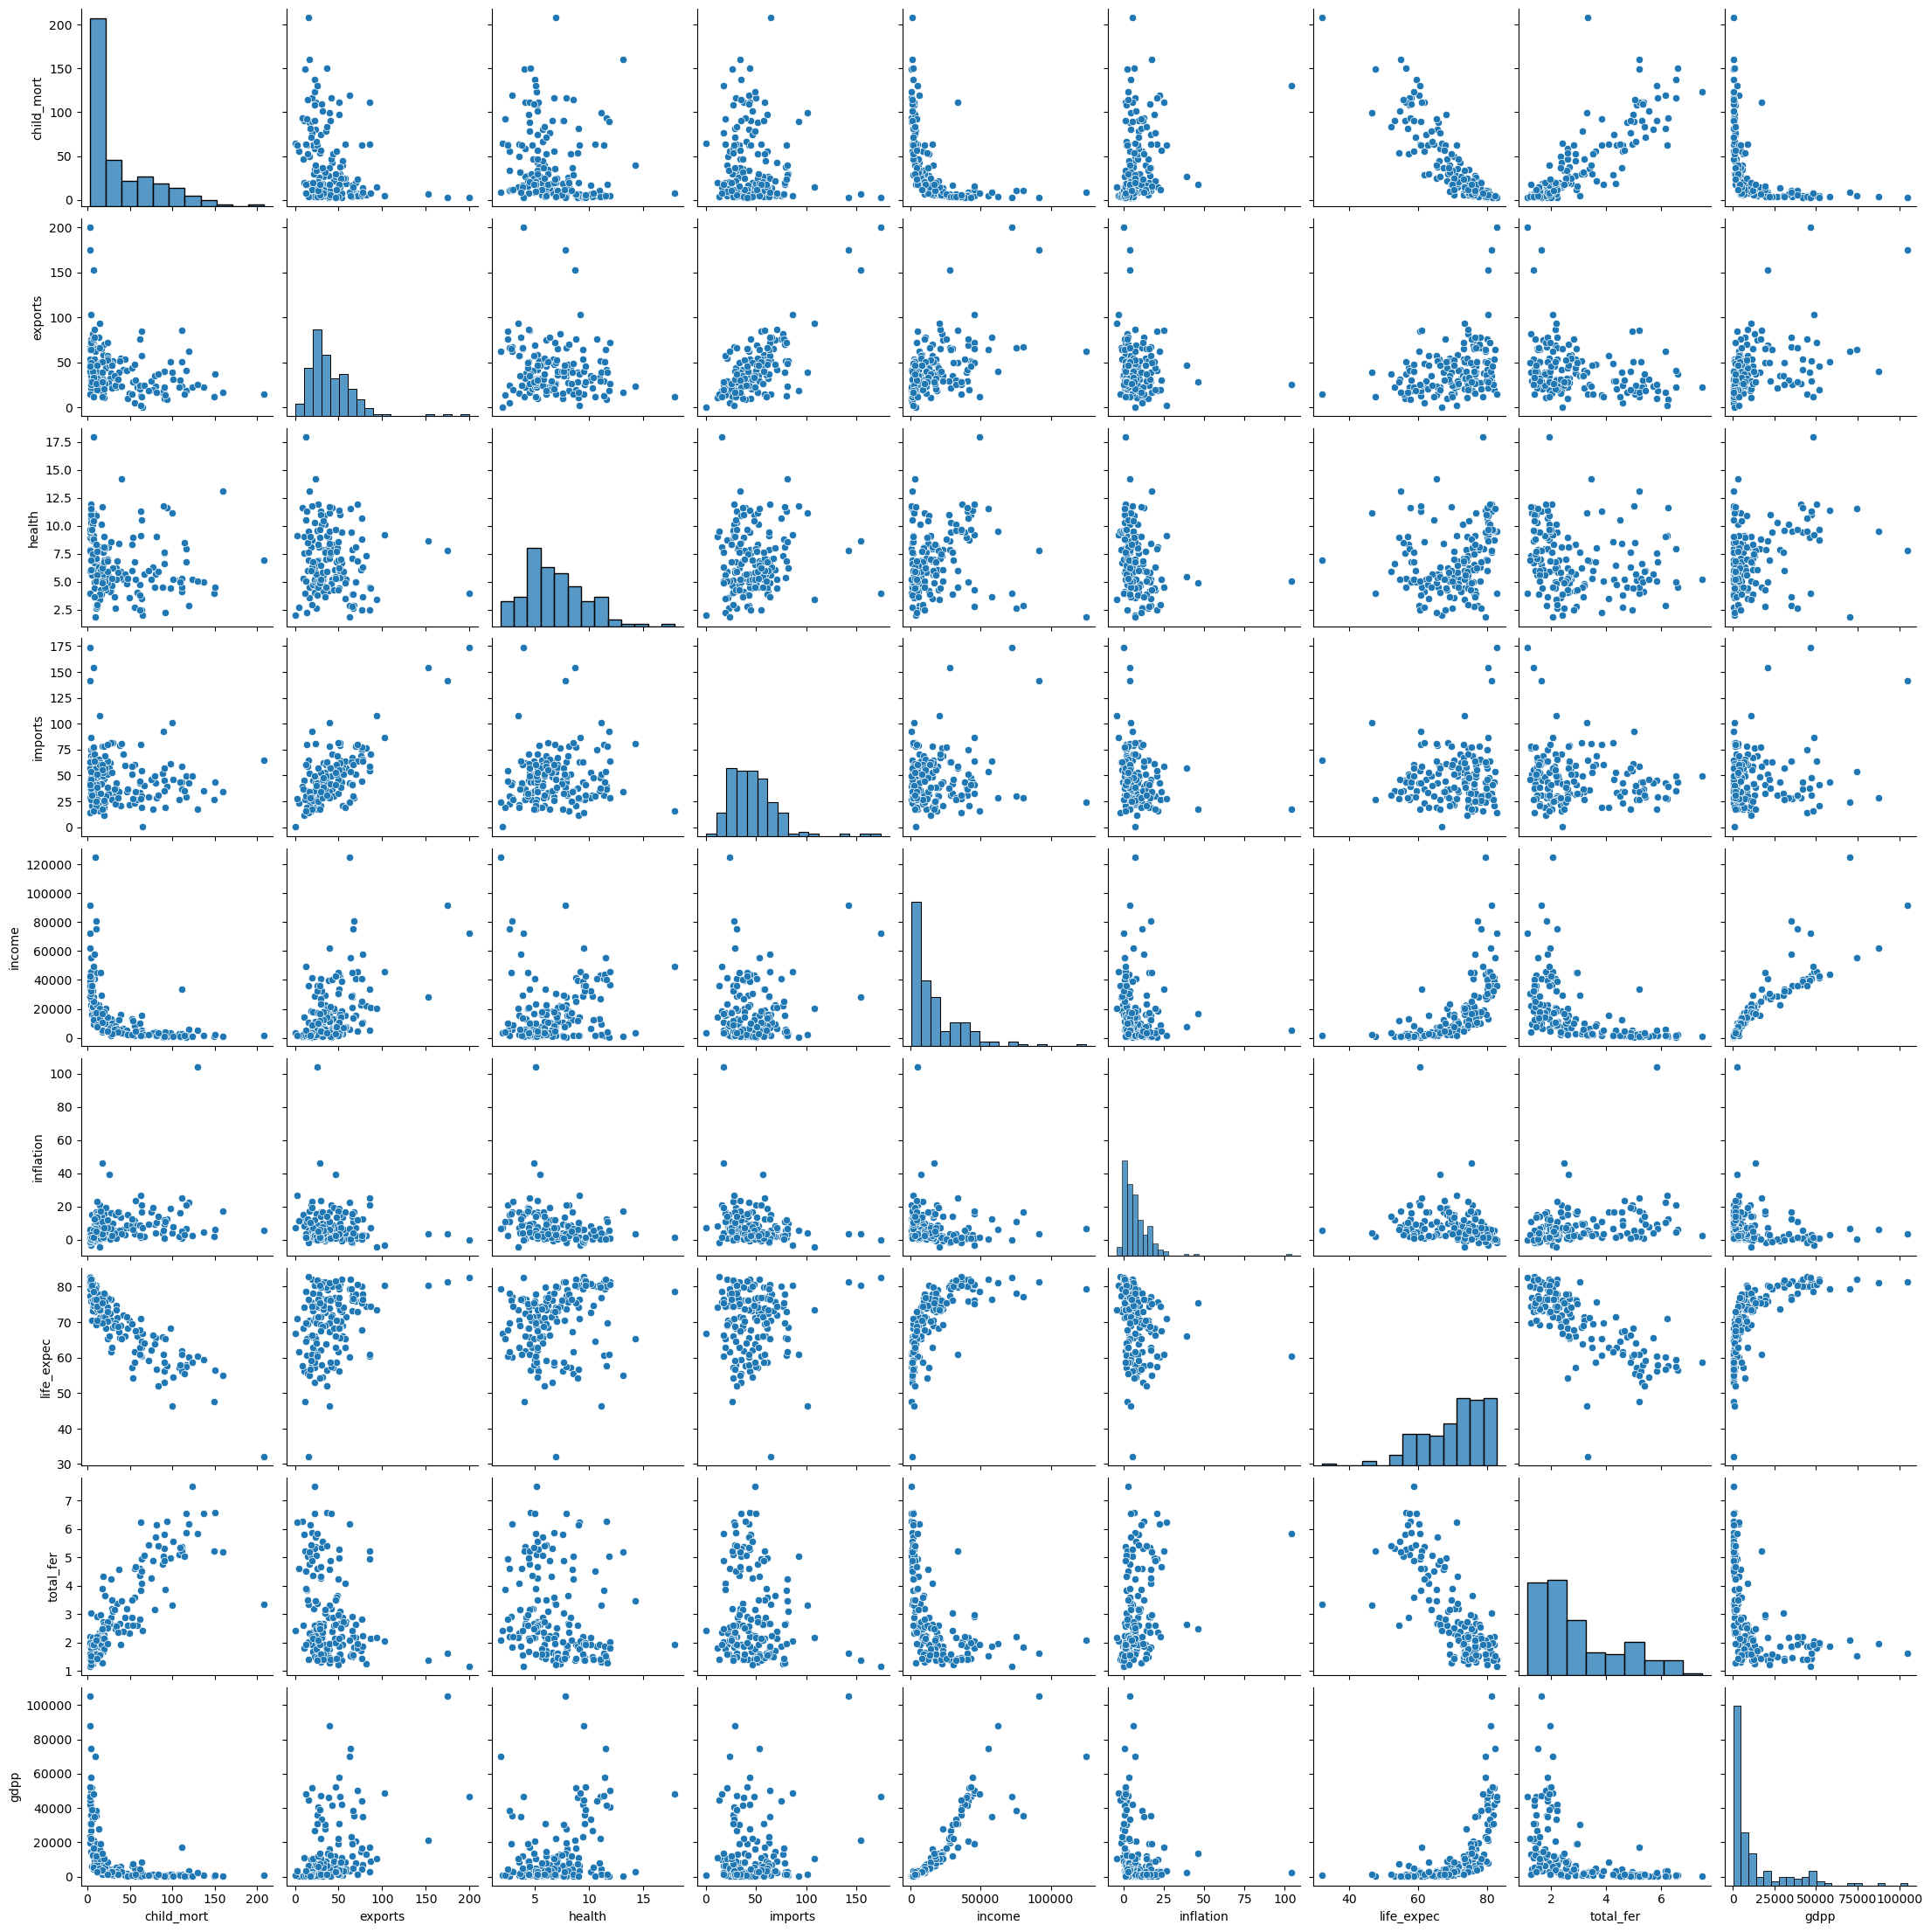

In [12]:
# import graphing tools
import matplotlib.pyplot as plt
import seaborn as sns
# pair plot
sns.pairplot(country.select_dtypes(exclude=['object']))
plt.show()

# Descriptive Statistics

In [13]:
country.describe(percentiles=[0.10, .25, .50, .75, .90 ,.95, .99])

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
10%,4.200000,15.660000,3.726000,22.520000,1524.000000,0.587800,57.820000,1.452000,593.800000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
90%,100.220000,70.800000,10.940000,75.420000,41220.000000,16.640000,80.400000,5.322000,41840.000000
95%,116.000000,80.570000,11.570000,81.140000,48290.000000,20.870000,81.400000,5.861000,48610.000000


## Correlation

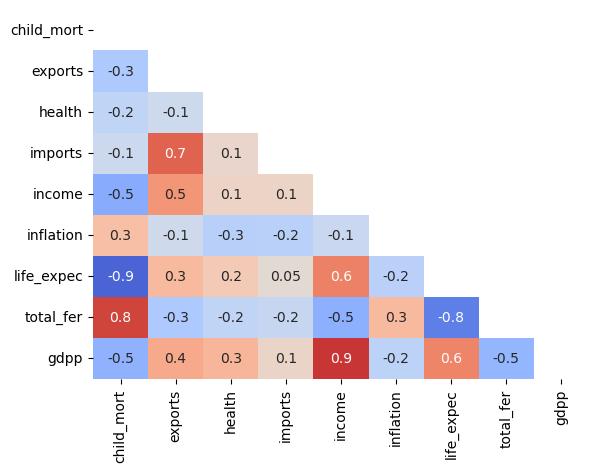

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


In [14]:
# import numpy
import numpy as np
matrix = np.triu(country.select_dtypes(exclude=['object']).corr(method='pearson'))
sns.heatmap(country.select_dtypes(exclude=['object']).corr(method='pearson'),annot=True, vmin=-1, vmax=1, center= 0, mask=matrix, cmap='coolwarm', cbar=False, fmt='.1g')
plt.show()
country.select_dtypes(exclude=['object']).corr()

# Top 25

In [15]:
# function for table & graph
def top_25(feature):
        max_data = country.sort_values(feature, ascending=False).head(25)
        plt.figure(figsize=(4,5))
        sns.barplot(y='country', x=feature, data=max_data)
        title = '25 countries with highest ' + feature
        plt.title(title)
        plt.show()
        display(max_data)
        min_data = country.sort_values(feature, ascending=True).head(25)
        plt.figure(figsize=(4,5))
        sns.barplot(y='country', x=feature, data=min_data)
        title = '25 countries with lowest ' + feature
        plt.title(title)
        plt.show()
        display(min_data)

## Child Mortality 

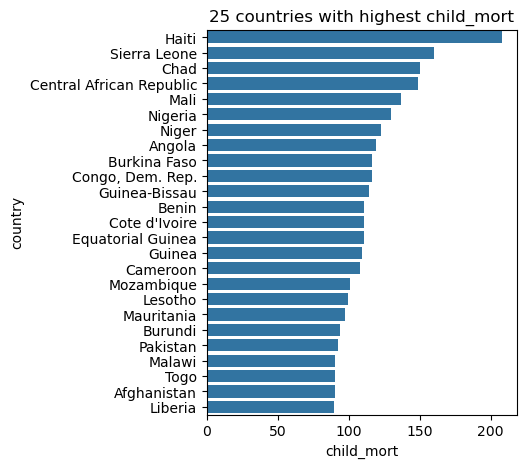

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
66,Haiti,208.0,15.30,6.91,64.7,1500,5.450,32.1,3.33,662
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399
32,Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446
97,Mali,137.0,22.80,4.98,35.1,1870,4.370,59.5,6.55,708
113,Nigeria,130.0,25.30,5.07,17.4,5150,104.000,60.5,5.84,2330
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530
25,Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334


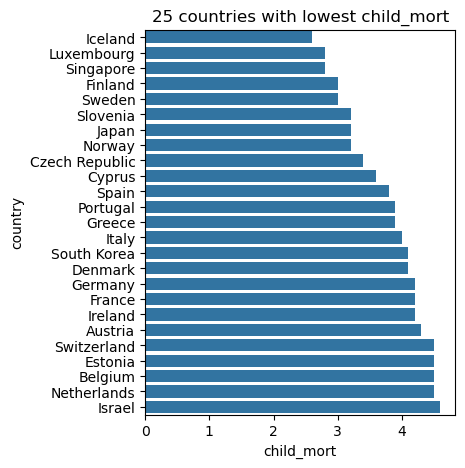

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
68,Iceland,2.6,53.4,9.40,43.3,38800,5.470,82.0,2.20,41900
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
53,Finland,3.0,38.7,8.95,37.4,39800,0.351,80.0,1.87,46200
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,81.5,1.98,52100
135,Slovenia,3.2,64.3,9.41,62.9,28700,-0.987,79.5,1.57,23400
77,Japan,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500
114,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800
43,Czech Republic,3.4,66.0,7.88,62.9,28300,-1.430,77.5,1.51,19800
42,Cyprus,3.6,50.2,5.97,57.5,33900,2.010,79.9,1.42,30800


In [16]:
top_25('child_mort')

## Exports

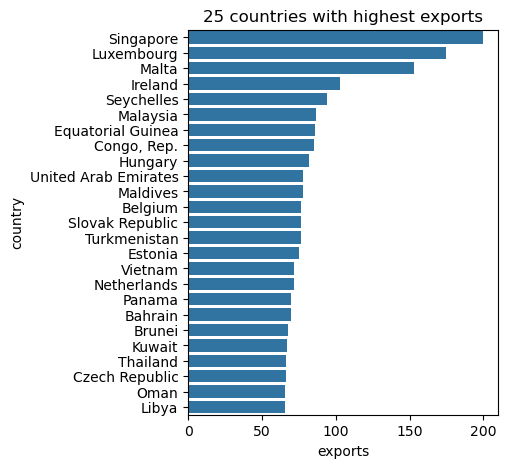

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
98,Malta,6.8,153.0,8.65,154.0,28300,3.830,80.3,1.36,21100
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700
131,Seychelles,14.4,93.8,3.40,108.0,20400,-4.210,73.4,2.17,10800
95,Malaysia,7.9,86.9,4.39,71.0,21100,7.270,74.5,2.15,9070
49,Equatorial Guinea,111.0,85.8,4.48,58.9,33700,24.900,60.9,5.21,17100
38,"Congo, Rep.",63.9,85.1,2.46,54.7,5190,20.700,60.4,4.95,2740
67,Hungary,6.0,81.8,7.33,76.5,22300,2.330,74.5,1.25,13100
157,United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000


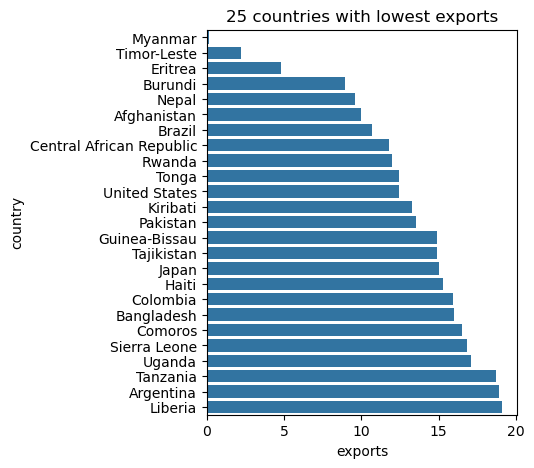

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
107,Myanmar,64.4,0.109,1.97,0.0659,3720,7.04,66.8,2.41,988
149,Timor-Leste,62.6,2.200,9.12,27.8000,1850,26.50,71.1,6.23,3600
50,Eritrea,55.2,4.790,2.66,23.3000,1420,11.60,61.7,4.61,482
26,Burundi,93.6,8.920,11.60,39.2000,764,12.30,57.7,6.26,231
109,Nepal,47.0,9.580,5.25,36.4000,1990,15.10,68.3,2.61,592
0,Afghanistan,90.2,10.000,7.58,44.9000,1610,9.44,56.2,5.82,553
22,Brazil,19.8,10.700,9.01,11.8000,14500,8.41,74.2,1.80,11200
31,Central African Republic,149.0,11.800,3.98,26.5000,888,2.01,47.5,5.21,446
126,Rwanda,63.6,12.000,10.50,30.0000,1350,2.61,64.6,4.51,563
151,Tonga,17.4,12.400,5.07,60.3000,4980,3.68,69.9,3.91,3550


In [17]:
top_25('exports')

## Health

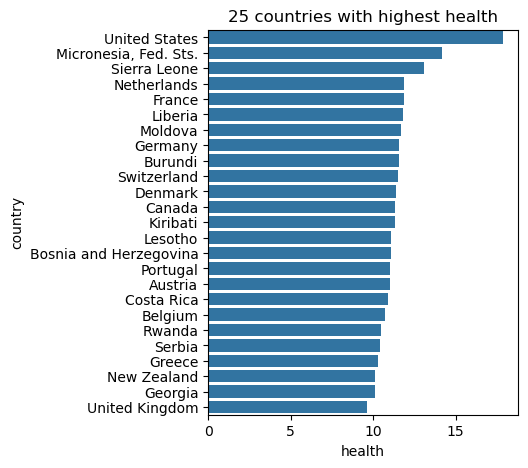

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
159,United States,7.3,12.40,17.90,15.8,49400,1.220,78.7,1.93,48400
101,"Micronesia, Fed. Sts.",40.0,23.50,14.20,81.0,3340,3.800,65.4,3.46,2860
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399
110,Netherlands,4.5,72.00,11.90,63.6,45500,0.848,80.7,1.79,50300
54,France,4.2,26.80,11.90,28.1,36900,1.050,81.4,2.03,40600
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327
102,Moldova,17.2,39.20,11.70,78.5,3910,11.100,69.7,1.27,1630
58,Germany,4.2,42.30,11.60,37.1,40400,0.758,80.1,1.39,41800
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231
145,Switzerland,4.5,64.00,11.50,53.3,55500,0.317,82.2,1.52,74600


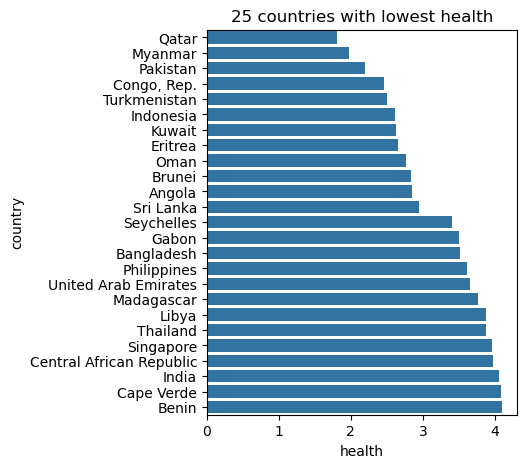

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
123,Qatar,9.0,62.300,1.81,23.8000,125000,6.980,79.5,2.07,70300
107,Myanmar,64.4,0.109,1.97,0.0659,3720,7.040,66.8,2.41,988
116,Pakistan,92.1,13.500,2.20,19.4000,4280,10.900,65.3,3.85,1040
38,"Congo, Rep.",63.9,85.100,2.46,54.7000,5190,20.700,60.4,4.95,2740
154,Turkmenistan,62.0,76.300,2.50,44.5000,9940,2.310,67.9,2.83,4440
70,Indonesia,33.3,24.300,2.61,22.4000,8430,15.300,69.9,2.48,3110
82,Kuwait,10.8,66.700,2.63,30.4000,75200,11.200,78.2,2.21,38500
50,Eritrea,55.2,4.790,2.66,23.3000,1420,11.600,61.7,4.61,482
115,Oman,11.7,65.700,2.77,41.2000,45300,15.600,76.1,2.90,19300
23,Brunei,10.5,67.400,2.84,28.0000,80600,16.700,77.1,1.84,35300


In [18]:
top_25('health')

## Imports

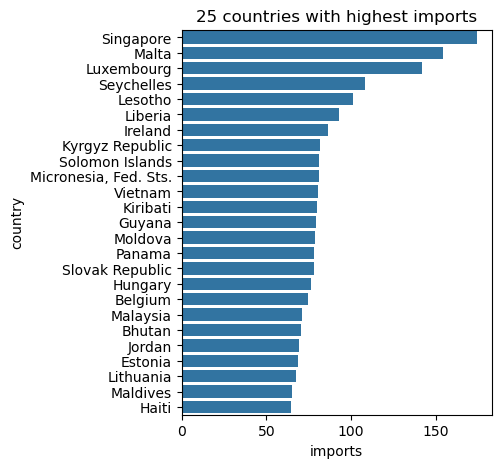

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
98,Malta,6.8,153.0,8.65,154.0,28300,3.830,80.3,1.36,21100
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
131,Seychelles,14.4,93.8,3.40,108.0,20400,-4.210,73.4,2.17,10800
87,Lesotho,99.7,39.4,11.10,101.0,2380,4.150,46.5,3.30,1170
88,Liberia,89.3,19.1,11.80,92.6,700,5.470,60.8,5.02,327
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700
83,Kyrgyz Republic,29.6,51.6,6.18,81.7,2790,10.000,68.5,3.10,880
136,Solomon Islands,28.1,49.3,8.55,81.2,1780,6.810,61.7,4.24,1290
101,"Micronesia, Fed. Sts.",40.0,23.5,14.20,81.0,3340,3.800,65.4,3.46,2860


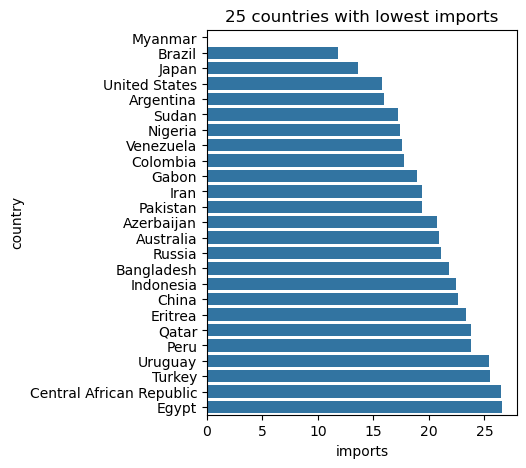

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
107,Myanmar,64.4,0.109,1.97,0.0659,3720,7.04,66.8,2.41,988
22,Brazil,19.8,10.700,9.01,11.8000,14500,8.41,74.2,1.80,11200
77,Japan,3.2,15.000,9.49,13.6000,35800,-1.90,82.8,1.39,44500
159,United States,7.3,12.400,17.90,15.8000,49400,1.22,78.7,1.93,48400
5,Argentina,14.5,18.900,8.10,16.0000,18700,20.90,75.8,2.37,10300
142,Sudan,76.7,19.700,6.32,17.2000,3370,19.60,66.3,4.88,1480
113,Nigeria,130.0,25.300,5.07,17.4000,5150,104.00,60.5,5.84,2330
163,Venezuela,17.1,28.500,4.91,17.6000,16500,45.90,75.4,2.47,13500
35,Colombia,18.6,15.900,7.59,17.8000,10900,3.86,76.4,2.01,6250
55,Gabon,63.7,57.700,3.50,18.9000,15400,16.60,62.9,4.08,8750


In [19]:
top_25('imports')

## Income

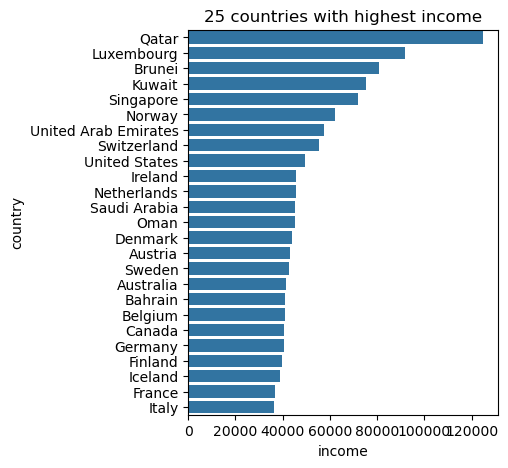

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
123,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
23,Brunei,10.5,67.4,2.84,28.0,80600,16.700,77.1,1.84,35300
82,Kuwait,10.8,66.7,2.63,30.4,75200,11.200,78.2,2.21,38500
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
114,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800
157,United Arab Emirates,8.6,77.7,3.66,63.6,57600,12.500,76.5,1.87,35000
145,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
159,United States,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700


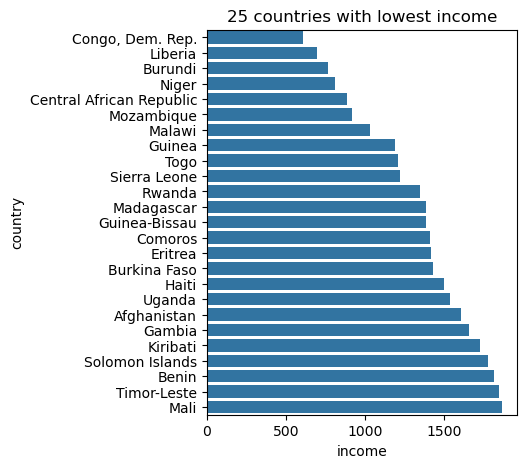

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446
106,Mozambique,101.0,31.50,5.21,46.2,918,7.640,54.5,5.56,419
94,Malawi,90.5,22.80,6.59,34.9,1030,12.100,53.1,5.31,459
63,Guinea,109.0,30.30,4.93,43.2,1190,16.100,58.0,5.34,648
150,Togo,90.3,40.20,7.65,57.3,1210,1.180,58.7,4.87,488
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399


In [20]:
top_25('income')

## Inflation

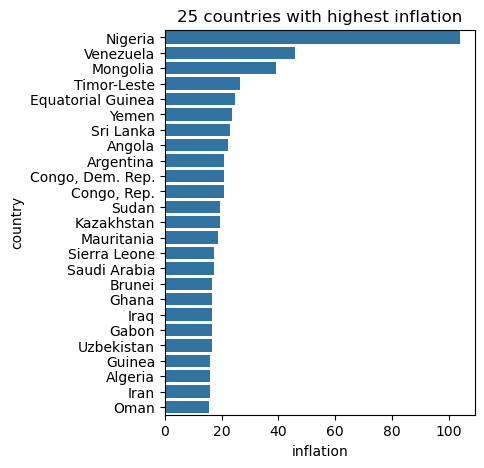

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
113,Nigeria,130.0,25.3,5.07,17.4,5150,104.0,60.5,5.84,2330
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.9,75.4,2.47,13500
103,Mongolia,26.1,46.7,5.44,56.7,7710,39.2,66.2,2.64,2650
149,Timor-Leste,62.6,2.2,9.12,27.8,1850,26.5,71.1,6.23,3600
49,Equatorial Guinea,111.0,85.8,4.48,58.9,33700,24.9,60.9,5.21,17100
165,Yemen,56.3,30.0,5.18,34.4,4480,23.6,67.5,4.67,1310
140,Sri Lanka,11.2,19.6,2.94,26.8,8560,22.8,74.4,2.20,2810
3,Angola,119.0,62.3,2.85,42.9,5900,22.4,60.1,6.16,3530
5,Argentina,14.5,18.9,8.10,16.0,18700,20.9,75.8,2.37,10300
37,"Congo, Dem. Rep.",116.0,41.1,7.91,49.6,609,20.8,57.5,6.54,334


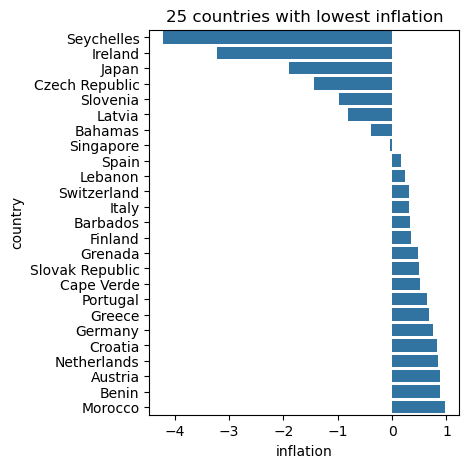

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
131,Seychelles,14.4,93.8,3.40,108.0,20400,-4.210,73.4,2.17,10800
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700
77,Japan,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500
43,Czech Republic,3.4,66.0,7.88,62.9,28300,-1.430,77.5,1.51,19800
135,Slovenia,3.2,64.3,9.41,62.9,28700,-0.987,79.5,1.57,23400
85,Latvia,7.8,53.7,6.68,55.1,18300,-0.812,73.1,1.36,11300
10,Bahamas,13.8,35.0,7.89,43.7,22900,-0.393,73.8,1.86,28000
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
139,Spain,3.8,25.5,9.54,26.8,32500,0.160,81.9,1.37,30700
86,Lebanon,10.3,35.8,7.03,60.2,16300,0.238,79.8,1.61,8860


In [21]:
top_25('inflation')

## Life Expectancy

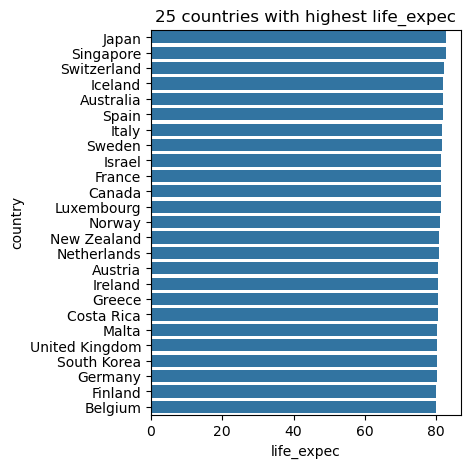

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
77,Japan,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
145,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
68,Iceland,2.6,53.4,9.40,43.3,38800,5.470,82.0,2.20,41900
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
139,Spain,3.8,25.5,9.54,26.8,32500,0.160,81.9,1.37,30700
75,Italy,4.0,25.2,9.53,27.2,36200,0.319,81.7,1.46,35800
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,81.5,1.98,52100
74,Israel,4.6,35.0,7.63,32.9,29600,1.770,81.4,3.03,30600
54,France,4.2,26.8,11.90,28.1,36900,1.050,81.4,2.03,40600


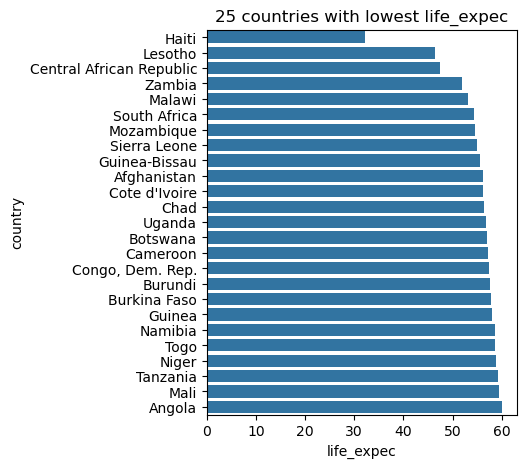

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
66,Haiti,208.0,15.30,6.91,64.7,1500,5.45,32.1,3.33,662
87,Lesotho,99.7,39.40,11.10,101.0,2380,4.15,46.5,3.30,1170
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.01,47.5,5.21,446
166,Zambia,83.1,37.00,5.89,30.9,3280,14.00,52.0,5.40,1460
94,Malawi,90.5,22.80,6.59,34.9,1030,12.10,53.1,5.31,459
137,South Africa,53.7,28.60,8.94,27.4,12000,6.35,54.3,2.59,7280
106,Mozambique,101.0,31.50,5.21,46.2,918,7.64,54.5,5.56,419
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.20,55.0,5.20,399
64,Guinea-Bissau,114.0,14.90,8.50,35.2,1390,2.97,55.6,5.05,547
0,Afghanistan,90.2,10.00,7.58,44.9,1610,9.44,56.2,5.82,553


In [22]:
top_25('life_expec')

## Total Fertility

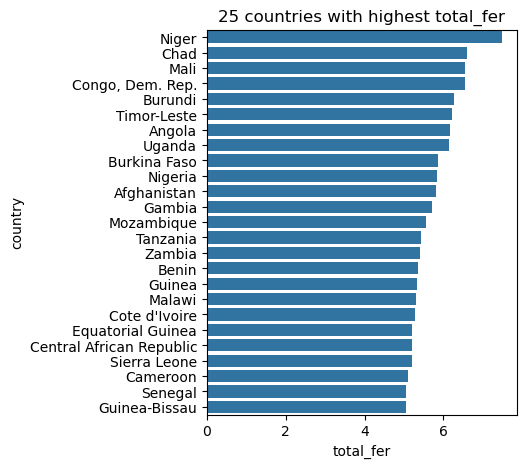

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
32,Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897
97,Mali,137.0,22.80,4.98,35.1,1870,4.370,59.5,6.55,708
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231
149,Timor-Leste,62.6,2.20,9.12,27.8,1850,26.500,71.1,6.23,3600
3,Angola,119.0,62.30,2.85,42.9,5900,22.400,60.1,6.16,3530
155,Uganda,81.0,17.10,9.01,28.6,1540,10.600,56.8,6.15,595
25,Burkina Faso,116.0,19.20,6.74,29.6,1430,6.810,57.9,5.87,575
113,Nigeria,130.0,25.30,5.07,17.4,5150,104.000,60.5,5.84,2330


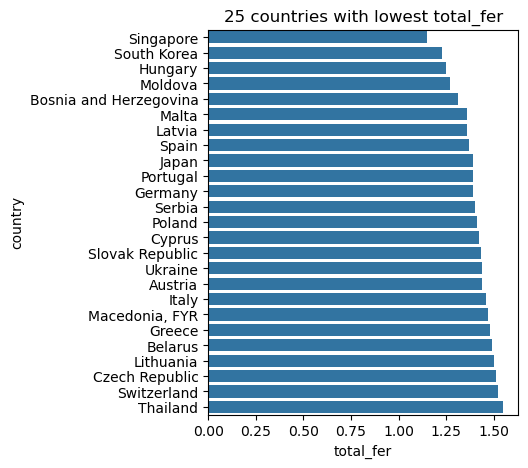

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
133,Singapore,2.8,200.0,3.96,174.0,72100,-0.046,82.7,1.15,46600
138,South Korea,4.1,49.4,6.93,46.2,30400,3.160,80.1,1.23,22100
67,Hungary,6.0,81.8,7.33,76.5,22300,2.330,74.5,1.25,13100
102,Moldova,17.2,39.2,11.70,78.5,3910,11.100,69.7,1.27,1630
20,Bosnia and Herzegovina,6.9,29.7,11.10,51.3,9720,1.400,76.8,1.31,4610
98,Malta,6.8,153.0,8.65,154.0,28300,3.830,80.3,1.36,21100
85,Latvia,7.8,53.7,6.68,55.1,18300,-0.812,73.1,1.36,11300
139,Spain,3.8,25.5,9.54,26.8,32500,0.160,81.9,1.37,30700
77,Japan,3.2,15.0,9.49,13.6,35800,-1.900,82.8,1.39,44500
122,Portugal,3.9,29.9,11.00,37.4,27200,0.643,79.8,1.39,22500


In [23]:
top_25('total_fer')

## GDP per Capita

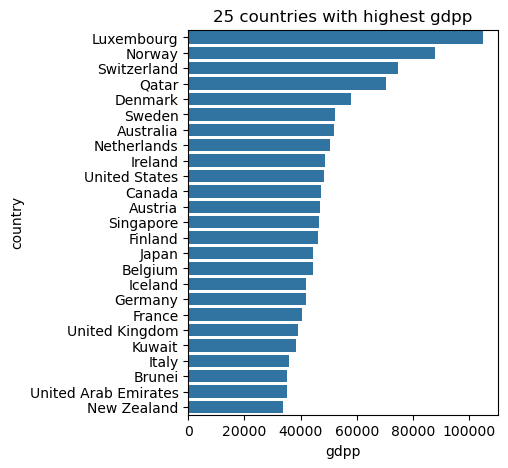

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000
114,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800
145,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600
123,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,81.5,1.98,52100
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
110,Netherlands,4.5,72.0,11.90,63.6,45500,0.848,80.7,1.79,50300
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700
159,United States,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400


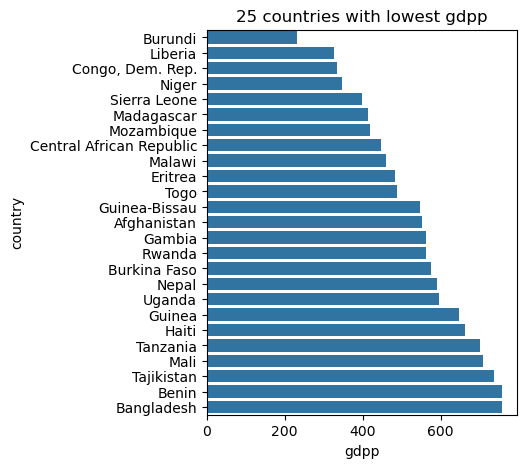

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
26,Burundi,93.6,8.92,11.60,39.2,764,12.300,57.7,6.26,231
88,Liberia,89.3,19.10,11.80,92.6,700,5.470,60.8,5.02,327
37,"Congo, Dem. Rep.",116.0,41.10,7.91,49.6,609,20.800,57.5,6.54,334
112,Niger,123.0,22.20,5.16,49.1,814,2.550,58.8,7.49,348
132,Sierra Leone,160.0,16.80,13.10,34.5,1220,17.200,55.0,5.20,399
93,Madagascar,62.2,25.00,3.77,43.0,1390,8.790,60.8,4.60,413
106,Mozambique,101.0,31.50,5.21,46.2,918,7.640,54.5,5.56,419
31,Central African Republic,149.0,11.80,3.98,26.5,888,2.010,47.5,5.21,446
94,Malawi,90.5,22.80,6.59,34.9,1030,12.100,53.1,5.31,459
50,Eritrea,55.2,4.79,2.66,23.3,1420,11.600,61.7,4.61,482


In [24]:
top_25('gdpp')

# Unsupervised Learning

In [25]:
# import Kmeans, Scaler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
# preprocessing pipeline (scale, PCA)
preprocessing_pipeline_steps = []
preprocessing_pipeline_steps.append(('scaler', StandardScaler()))
preprocessing_pipeline_steps.append(('pca', PCA(n_components=9)))
preprocessing_pipeline = Pipeline(steps=preprocessing_pipeline_steps)
# scaled, PCA data
country_scaled = preprocessing_pipeline.fit_transform(country.drop('country', axis='columns'))

## Kmeans

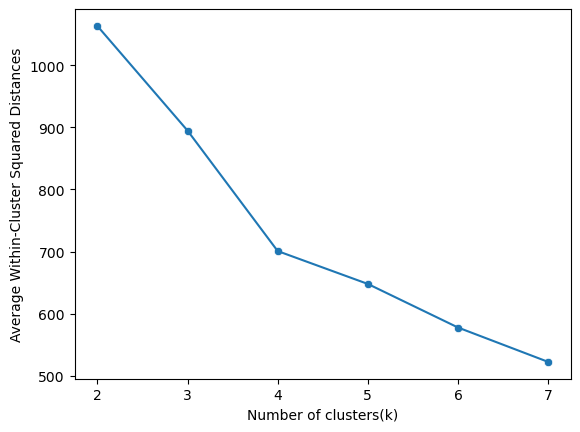

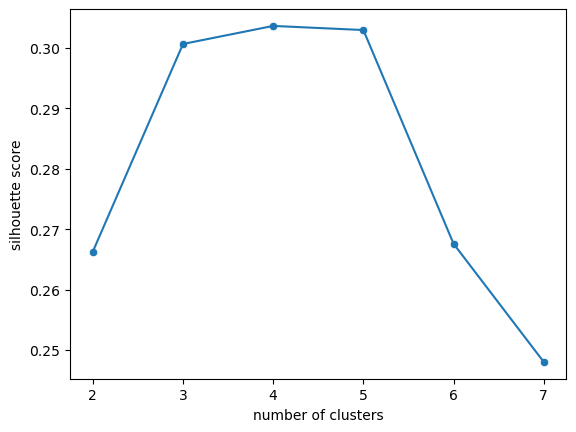

In [26]:
# import
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# Find number of clusters
inertia = []
sil_scores = []
for n_clusters in range(2, 8):
    kmeans = KMeans(n_clusters=n_clusters,
                        random_state=0, max_iter=20).fit(country_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(country_scaled, kmeans.labels_))

# inertias dataframe
inertias = pd.DataFrame({'n_clusters': range(2, 8), 'inertia': inertia})
# plot inertias
sns.lineplot(x='n_clusters', y='inertia', data=inertias, markers=True)
sns.scatterplot(x='n_clusters', y='inertia', data=inertias, markers=True)
plt.xlabel('Number of clusters(k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.show()
# plot silhouette scores
sns.lineplot(x=range(2,8), y=sil_scores, markers=True)
sns.scatterplot(x=range(2,8), y=sil_scores, markers=True)
plt.xlabel('number of clusters')
plt.ylabel('silhouette score')
plt.show()

In [27]:
kmeans = KMeans(n_clusters=4, random_state=0, max_iter=20).fit(country_scaled)
kmeans_labels = kmeans.labels_ + 1

## Hierarchial Clustering

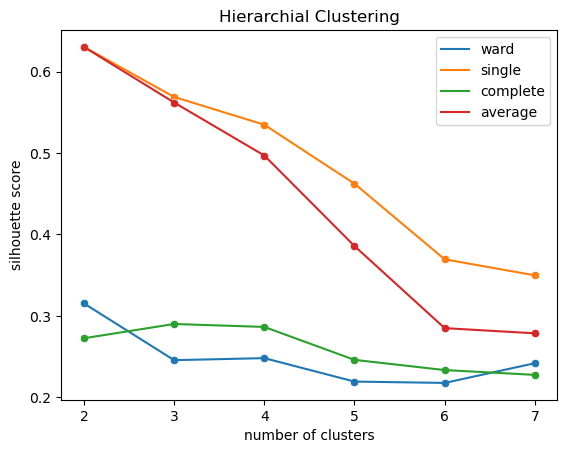

In [28]:
# import
from sklearn.cluster import AgglomerativeClustering

linkages = ['ward', 'single', 'complete', 'average']
for link in linkages:
    sil_scores = []
    for i in range(2,8):
        cluster = AgglomerativeClustering(n_clusters=i, linkage=link)
        hier_model = cluster.fit(country_scaled)
        labels = hier_model.labels_
        sil_scores.append(silhouette_score(country_scaled, labels))

    sns.lineplot(x=range(2,8), y=sil_scores, markers=True, label=link)
    sns.scatterplot(x=range(2,8), y=sil_scores, markers=True)
    plt.title('Hierarchial Clustering')
    plt.xlabel('number of clusters')
    plt.ylabel('silhouette score')
plt.show()

In [29]:
cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_model = cluster.fit(country_scaled)
hier_labels = hier_model.labels_ + 1

# TSNE

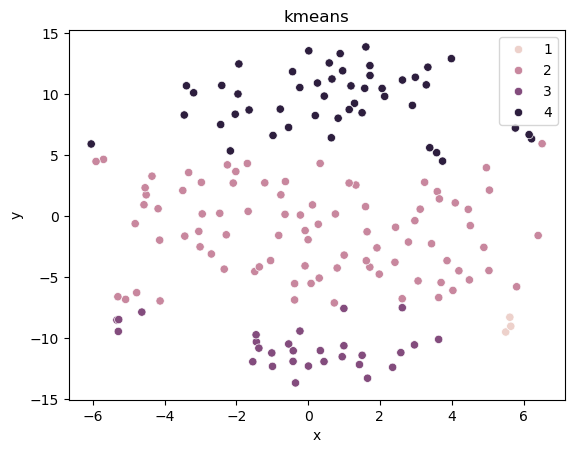

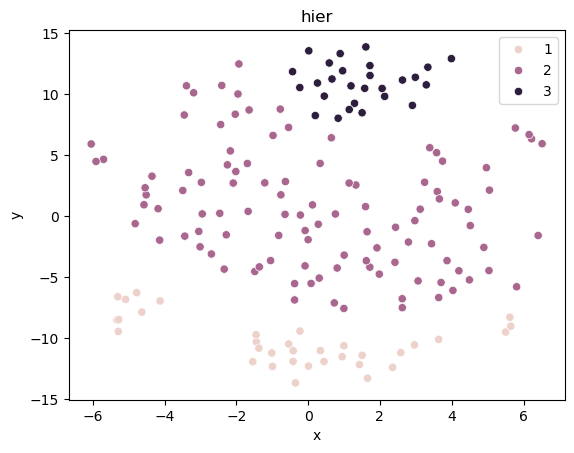

In [30]:
from sklearn.manifold import TSNE
country_tsne = pd.DataFrame(TSNE(n_components=2).fit_transform(country_scaled), columns=['x','y'])

# kmeans
sns.scatterplot(x='x',y='y', data=country_tsne, hue=kmeans_labels)
plt.title('kmeans')
plt.show()

# hier
sns.scatterplot(x='x',y='y', data=country_tsne, hue=hier_labels)
plt.title('hier')
plt.show()

# Analysing Clusters
Based on the TSNE graphs of the clusters, the clusters of Hierarchial Clustering, 3 clusters, looks the best in terms of accurately labeling a certain group of points. KMeans, 4 clusters, is a close 2nd, but the one of the clusters looks to be part of a bigger cluster.

In [31]:
# labels used
labels_used = hier_labels
# concat labels to data set
country_with_labels = pd.concat([country, pd.Series(labels_used)], axis='columns')
country_with_labels.rename({0:'cluster'}, axis='columns', inplace=True)

## Summary of Clusters

### Cluster 1

In [32]:
# Cluster 1
display(country_with_labels[country_with_labels.cluster==1].sort_values('gdpp',ascending=False))
country_with_labels[country_with_labels.cluster==1].describe()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
91,Luxembourg,2.8,175.0,7.77,142.0,91700,3.620,81.3,1.63,105000,1
114,Norway,3.2,39.7,9.48,28.5,62300,5.950,81.0,1.95,87800,1
145,Switzerland,4.5,64.0,11.50,53.3,55500,0.317,82.2,1.52,74600,1
123,Qatar,9.0,62.3,1.81,23.8,125000,6.980,79.5,2.07,70300,1
44,Denmark,4.1,50.5,11.40,43.6,44000,3.220,79.5,1.87,58000,1
144,Sweden,3.0,46.2,9.63,40.7,42900,0.991,81.5,1.98,52100,1
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900,1
110,Netherlands,4.5,72.0,11.90,63.6,45500,0.848,80.7,1.79,50300,1
73,Ireland,4.2,103.0,9.19,86.5,45700,-3.220,80.4,2.05,48700,1
159,United States,7.3,12.4,17.90,15.8,49400,1.220,78.7,1.93,48400,1


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.0
mean,5.961765,58.508824,8.501176,48.902941,47588.235294,4.115500,79.982353,1.888529,43170.588235,1.0
std,3.557409,43.050973,3.561755,37.660159,20575.916559,5.467657,2.086242,0.456244,19466.000343,0.0
min,2.600000,12.400000,1.810000,13.600000,27200.000000,-3.220000,75.100000,1.150000,12100.000000,1.0
25%,3.900000,29.300000,5.635000,28.200000,36200.000000,0.694250,79.500000,1.490000,31450.000000,1.0
50%,4.500000,50.050000,9.485000,37.250000,41250.000000,1.670000,80.400000,1.870000,41850.000000,1.0
75%,7.175000,67.225000,10.925000,50.125000,48475.000000,5.830000,81.400000,2.065000,48625.000000,1.0
max,16.600000,200.000000,17.900000,174.000000,125000.000000,17.200000,82.800000,3.030000,105000.000000,1.0


### Cluster 2

In [33]:
# Cluster 2
display(country_with_labels[country_with_labels.cluster==2].sort_values('gdpp',ascending=False))
country_with_labels[country_with_labels.cluster==2].describe()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
42,Cyprus,3.6,50.20,5.97,57.5,33900,2.010,79.9,1.42,30800,2
10,Bahamas,13.8,35.00,7.89,43.7,22900,-0.393,73.8,1.86,28000,2
135,Slovenia,3.2,64.30,9.41,62.9,28700,-0.987,79.5,1.57,23400,2
138,South Korea,4.1,49.40,6.93,46.2,30400,3.160,80.1,1.23,22100,2
43,Czech Republic,3.4,66.00,7.88,62.9,28300,-1.430,77.5,1.51,19800,2
...,...,...,...,...,...,...,...,...,...,...,...
12,Bangladesh,49.4,16.00,3.52,21.8,2440,7.140,70.4,2.33,758,2
146,Tajikistan,52.4,14.90,5.98,58.6,2110,12.500,69.6,3.51,738,2
109,Nepal,47.0,9.58,5.25,36.4,1990,15.100,68.3,2.61,592,2
50,Eritrea,55.2,4.79,2.66,23.3,1420,11.600,61.7,4.61,482,2


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
count,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.000000,106.0
mean,31.617925,39.990368,6.353679,48.085527,11341.886792,9.120604,70.921698,2.654623,6407.367925,2.0
std,27.407270,20.016658,2.324790,21.025201,7620.206486,12.397913,6.215204,1.160205,5853.217439,0.0
min,3.200000,0.109000,1.970000,0.065900,700.000000,-4.210000,46.500000,1.230000,327.000000,2.0
25%,12.075000,26.300000,4.872500,31.325000,5242.500000,2.432500,67.600000,1.762500,2672.500000,2.0
50%,20.500000,37.300000,6.015000,49.250000,9890.000000,6.045000,72.300000,2.395000,4520.000000,2.0
75%,43.975000,51.350000,7.850000,61.100000,16150.000000,11.975000,75.725000,3.182500,8637.500000,2.0
max,130.000000,93.800000,14.200000,108.000000,33900.000000,104.000000,80.400000,6.230000,30800.000000,2.0


### Cluster 3

In [34]:
# Cluster 3
display(country_with_labels[country_with_labels.cluster==3].sort_values('gdpp',ascending=False))
country_with_labels[country_with_labels.cluster==3].describe()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
166,Zambia,83.1,37.00,5.89,30.9,3280,14.000,52.0,5.40,1460,3
28,Cameroon,108.0,22.20,5.13,27.0,2660,1.910,57.3,5.11,1310,3
40,Cote d'Ivoire,111.0,50.60,5.30,43.3,2690,5.390,56.3,5.27,1220,3
129,Senegal,66.8,24.90,5.66,40.3,2180,1.850,64.0,5.06,1000,3
80,Kenya,62.2,20.70,4.75,33.6,2480,2.090,62.8,4.37,967,3
32,Chad,150.0,36.80,4.53,43.5,1930,6.390,56.5,6.59,897,3
36,Comoros,88.2,16.50,4.51,51.7,1410,3.870,65.9,4.75,769,3
17,Benin,111.0,23.80,4.10,37.2,1820,0.885,61.8,5.36,758,3
97,Mali,137.0,22.80,4.98,35.1,1870,4.370,59.5,6.55,708,3
147,Tanzania,71.9,18.70,6.01,29.1,2090,9.250,59.3,5.43,702,3


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster
count,27.000000,27.00000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.000000,27.0
mean,105.070370,23.58963,6.507037,39.662963,1589.740741,7.142778,57.248148,5.433704,667.888889,3.0
std,33.987914,10.35961,2.358064,9.555753,650.612114,5.423793,6.540076,0.834530,304.547121,0.0
min,62.200000,8.92000,3.770000,26.500000,609.000000,0.885000,32.100000,3.330000,231.000000,3.0
25%,82.050000,16.65000,4.955000,32.250000,1200.000000,2.580000,55.900000,5.055000,452.500000,3.0
50%,101.000000,22.20000,5.690000,39.200000,1430.000000,5.450000,57.700000,5.340000,575.000000,3.0
75%,116.000000,27.65000,7.615000,44.200000,1900.000000,10.020000,60.150000,5.845000,763.500000,3.0
max,208.000000,50.60000,13.100000,64.700000,3280.000000,20.800000,65.900000,7.490000,1460.000000,3.0


# Cluster Comparison

In [35]:
def anova_stat(feature):
    df1=country_with_labels[country_with_labels.cluster==1][feature]
    df2=country_with_labels[country_with_labels.cluster==2][feature]
    df3=country_with_labels[country_with_labels.cluster==3][feature]
    statistic, p_value = stats.f_oneway(df1, df2,df3)
    return np.round(p_value, 5)
def comp_cluster(feature):
    temp_data = country_with_labels.groupby('cluster', as_index=False)[feature].mean()
    sns.barplot(x='cluster', y=feature, data=temp_data)
    sup_title = 'Cluster Comparison of ' + feature
    title= 'Anova p-value: ' + str(anova_stat(feature))
    plt.suptitle(sup_title)
    plt.title(title)
    plt.show()
    display(temp_data)
import scipy.stats as stats


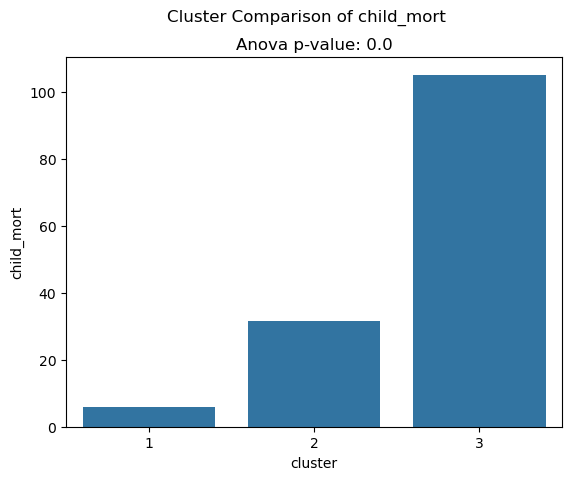

,cluster,child_mort
0,1,5.961765
1,2,31.617925
2,3,105.070370


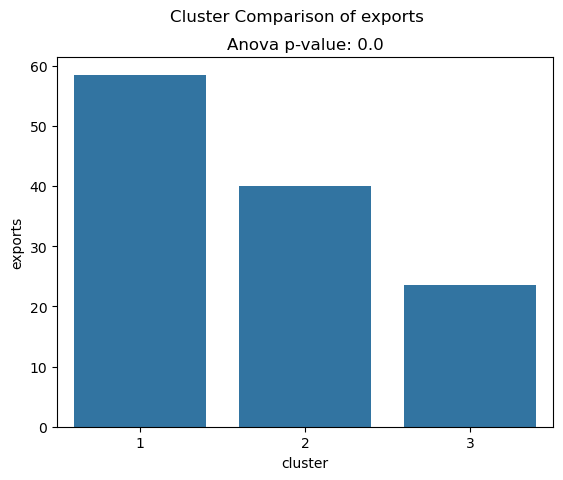

,cluster,exports
0,1,58.508824
1,2,39.990368
2,3,23.589630


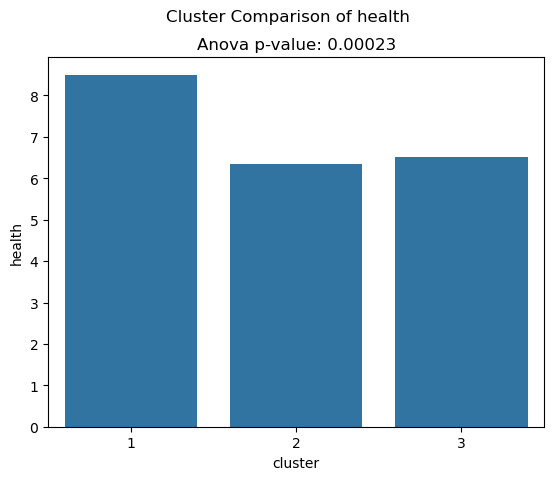

,cluster,health
0,1,8.501176
1,2,6.353679
2,3,6.507037


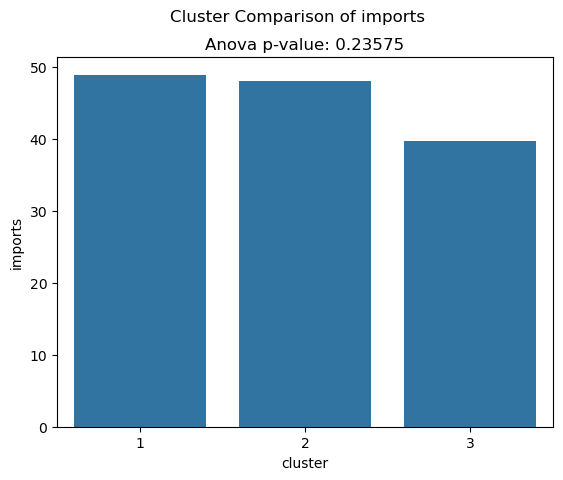

,cluster,imports
0,1,48.902941
1,2,48.085527
2,3,39.662963


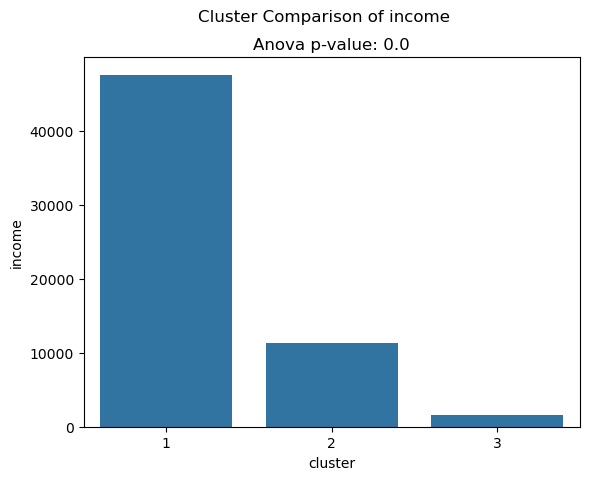

,cluster,income
0,1,47588.235294
1,2,11341.886792
2,3,1589.740741


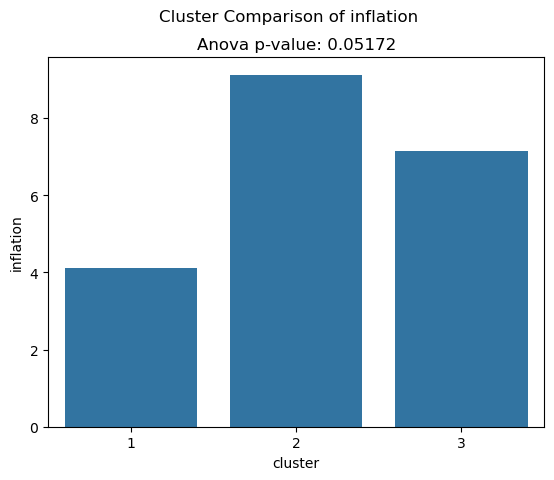

,cluster,inflation
0,1,4.115500
1,2,9.120604
2,3,7.142778


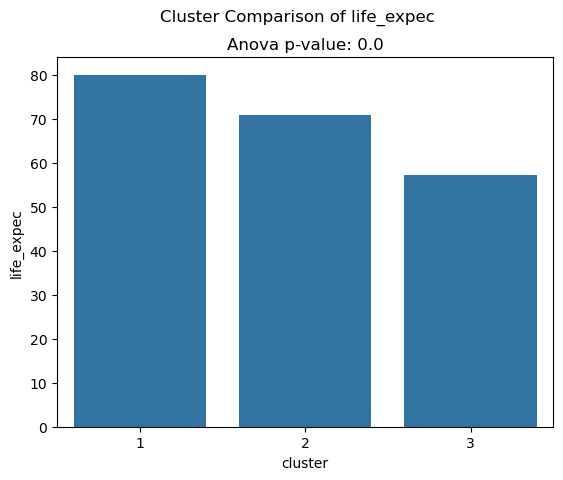

,cluster,life_expec
0,1,79.982353
1,2,70.921698
2,3,57.248148


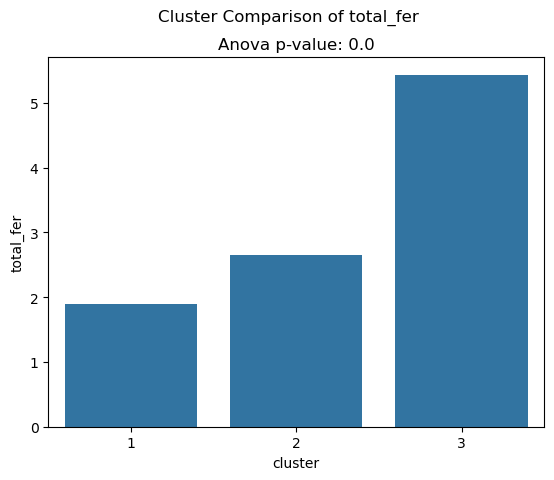

,cluster,total_fer
0,1,1.888529
1,2,2.654623
2,3,5.433704


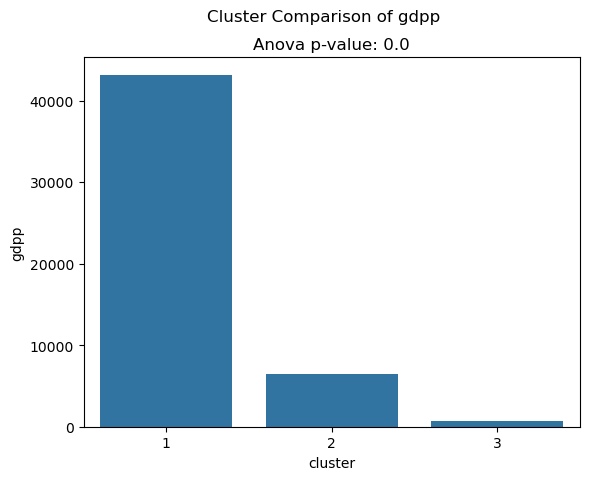

,cluster,gdpp
0,1,43170.588235
1,2,6407.367925
2,3,667.888889


In [36]:
features=['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
for feature in features:
    comp_cluster(feature)

# Recommendation
Based on the clusters, Cluster #3 seems to be in dire need of aid. It experiences very low GDP, high child mortality, very high fertility, and low life expectancy.